In [1]:
import numpy as np
import pandas as pd
from anndata import AnnData
import scanpy as sc
import multiprocessing as mp
from tqdm import tqdm

# load package

In [2]:
import os
import sys
sys.path.insert(1, '/home/nas3/biod/yangchenghui/proj2/UniG_master/src')
import unig as ug
ug.__version__

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'1.1'

In [3]:
workdir = '/home/nas3/biod/yangchenghui/proj2/proj2_on_mouse_embryonic/UniG_result/'
ug.settings.set_workdir(workdir)

Saving results in: /home/nas3/biod/yangchenghui/proj2/proj2_on_mouse_embryonic/UniG_result/


# Data preprocessing

In [4]:
data_path = "/home/nas3/biod/yangchenghui/proj2/conditon_data/Mouse_embryonic_brain/"
E15_RNA_data = sc.read_h5ad(data_path + 'E15_adata_rna.h5ad')
E15_ATAC_data = sc.read_h5ad(data_path + 'E15_adata_atac.h5ad')
E18_RNA_data = sc.read_h5ad(data_path + 'E18_adata_rna.h5ad')
E18_ATAC_data = sc.read_h5ad(data_path + 'E18_adata_atac.h5ad')
E15_RNA_data, E15_ATAC_data, E18_RNA_data, E18_ATAC_data

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(AnnData object with n_obs × n_vars = 1949 × 32285
     obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'Ground_Truth'
     var: 'type', 'name', 'interval', 'feature_id'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 1949 × 161461
     obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'src', 

RNA processing

For RNA data, genes with common names across all samples are first selected to ensure consistent identifiers; low‑expression genes are then filtered out, and the remaining expression matrix is normalized to correct for technical variations.

In [5]:
# genes_all_com = list(set(E15_RNA_data.var_names).intersection(set(E18_RNA_data.var_names)))
# print(len(genes_all_com))
# E15_RNA_data = E15_ATAC_data[:, genes_all_com].copy()
# E18_RNA_data = E18_ATAC_data[:, genes_all_com].copy()

E15_RNA_data = ug.pp.preprocess_rna(E15_RNA_data)
E18_RNA_data = ug.pp.preprocess_rna(E18_RNA_data)
E15_RNA_data, E18_RNA_data

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/anndata/_core/anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


(AnnData object with n_obs × n_vars = 1949 × 23033
     obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'Ground_Truth'
     var: 'type', 'name', 'interval', 'feature_id', 'n_cells', 'moran_I', 'spatial_qval', 'spatially_variable', 'spatially_variable_rank'
     uns: 'log1p', 'spatial_neighbors', 'moranI', 'svg_top_genes'
     obsm: 'spatial'
     obsp: 'spatial_connectivities', 'spatial_distances',
 AnnData object with n_obs × n_vars = 2129 × 25893
     obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRat

ATAC processing

For ATAC data, peaks are initially filtered, and subsequently only the peaks that are shared across all samples are retained for downstream analysis.

In [6]:
E15_ATAC_data = ug.pp.preprocess_atac(E15_ATAC_data)
E18_ATAC_data = ug.pp.preprocess_atac(E18_ATAC_data)

peaks_all = list(set(E15_ATAC_data.var_names).intersection(set(E18_ATAC_data.var_names)))
print(len(peaks_all))
                      
E15_ATAC_data = E15_ATAC_data[:, peaks_all].copy() 
E18_ATAC_data = E18_ATAC_data[:, peaks_all].copy()
E15_ATAC_data, E18_ATAC_data

161238


(AnnData object with n_obs × n_vars = 1949 × 161238
     obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'src', 'Ground Truth'
     var: 'n_cells', 'chr', 'start', 'end'
     obsm: 'spatial',
 AnnData object with n_obs × n_vars = 2129 × 161238
     obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'src'
 

For each variable gene, select ATAC peaks that fall within the gene body or in its upstream/downstream regions 

In [7]:
E15_top2000_genes = E15_RNA_data.var_names[E15_RNA_data.var['spatially_variable']].tolist()
E18_top2000_genes = E18_RNA_data.var_names[E18_RNA_data.var['spatially_variable']].tolist()
genes_selected = list(set(E15_top2000_genes).intersection(set(E18_top2000_genes)))
len(genes_selected)

897

In [8]:
gene_info = pd.read_csv('/home/nas3/biod/yangchenghui/nas2_ych/FGOT-master/data/P22mousebrain_data/mm10_TSS.txt', sep = '\t')
gene_info = gene_info.rename(columns={'start': 'starts','end': 'ends','Gene': 'genes'})
gene_info.head()

,chr,starts,ends,genes
1,chr1,3466587,3513553,Gm1992
2,chr1,3205901,3671498,Xkr4
3,chr1,3905739,3986215,Gm37381
4,chr1,4292981,4409187,Rp1_2
5,chr1,3999557,4409241,Rp1


In [9]:
filtered_genes, filtered_peaks, gene_peaks = ug.pp.select_gene_peaks_by_genes_location(gene_info, genes_selected, peaks_all)

Preprocessing gene_info:


27916it [00:00, 349268.85it/s]


Search the genes-peaks correspondence based on gene_info and scope:


27916it [00:57, 488.81it/s] 


Search the filtered peaks:


100%|██████████| 857/857 [00:00<00:00, 245896.74it/s]

There are 857 genes that can be identified from the TSS information.
There are 33327 peaks near the upstream and downstream of the above genes.


In [10]:
E15_rna_adata_fltr = E15_RNA_data[:,filtered_genes]
E18_rna_adata_fltr = E18_RNA_data[:,filtered_genes]
E15_atac_adata_fltr = E15_ATAC_data[:,filtered_peaks]
E18_atac_adata_fltr = E18_ATAC_data[:,filtered_peaks]
E15_rna_adata_fltr,E18_rna_adata_fltr,E15_atac_adata_fltr,E18_atac_adata_fltr

E15_rna_adata_fltr.write(workdir + "E15_RNA_adata_fltr.h5ad")
E15_atac_adata_fltr.write(workdir + "E15_ATAC_adata_fltr.h5ad")
E18_rna_adata_fltr.write(workdir + "E18_RNA_adata_fltr.h5ad")
E18_atac_adata_fltr.write(workdir + "E18_ATAC_adata_fltr.h5ad")

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c
/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


gene-peak relation

In [ ]:
from scipy import sparse
gene_to_idx = {gene: i for i, gene in enumerate(filtered_genes)}
peak_to_idx = {peak: i for i, peak in enumerate(filtered_peaks)}
rows = []
cols = []

filtered_peaks_set = set(filtered_peaks)
for gene in tqdm(filtered_genes):
    if gene in gene_peaks:
        current_peaks = gene_peaks[gene]
        valid_peaks = [p for p in current_peaks if p in peak_to_idx]
        if valid_peaks:
            g_idx = gene_to_idx[gene]
            p_idxs = [peak_to_idx[p] for p in valid_peaks]
            rows.extend([g_idx] * len(p_idxs))
            cols.extend(p_idxs)
data = np.ones(len(rows), dtype=int)
sparse_mat = sparse.coo_matrix((data, (rows, cols)), 
                               shape=(len(filtered_genes), len(filtered_peaks))).tocsr()
adata_GP = sc.AnnData(X=sparse_mat)
adata_GP.obs_names = filtered_genes
adata_GP.var_names = filtered_peaks
adata_GP.write(workdir+"adata_GenePeak_final.h5ad")
adata_GP

  1%|▏         | 12/857 [00:00<00:07, 114.42it/s]

100%|██████████| 857/857 [00:15<00:00, 56.32it/s]


AnnData object with n_obs × n_vars = 857 × 33327

gene expression discretization

/home/nas3/biod/yangchenghui/proj2/UniG_master/src/unig/utils.py:70: ImplicitModificationWarning: Setting element `.layers['unig']` of view, initializing view as actual.
  adata.layers['unig'] = X.copy()
/home/nas3/biod/yangchenghui/proj2/UniG_master/src/unig/utils.py:70: ImplicitModificationWarning: Setting element `.layers['unig']` of view, initializing view as actual.
  adata.layers['unig'] = X.copy()


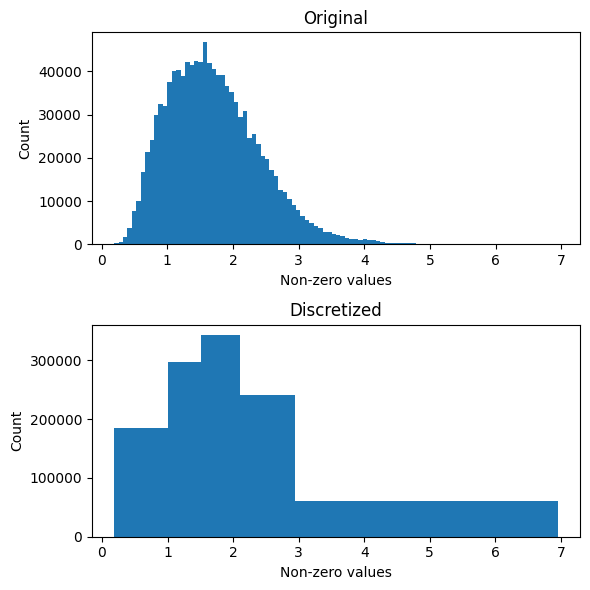

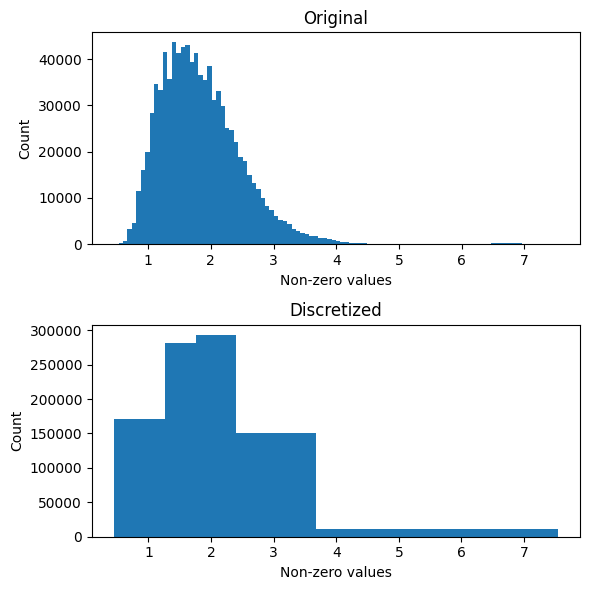

In [12]:
ug.tl.discretize(E15_rna_adata_fltr,n_bins=5)
ug.pl.discretize(E15_rna_adata_fltr,kde=False)

ug.tl.discretize(E18_rna_adata_fltr,n_bins=5)
ug.pl.discretize(E18_rna_adata_fltr,kde=False)

In [13]:
E15_rna_adata_fltr.write(workdir +"E15_RNA_adata_fltr_final.h5ad")
E18_rna_adata_fltr.write(workdir+"E18_RNA_adata_fltr_final.h5ad")

peak accessibility binarization

In [14]:
ug.pp.binarize(E15_atac_adata_fltr)
ug.pp.binarize(E18_atac_adata_fltr)

In [15]:
E15_atac_adata_fltr.write(workdir+"E15_ATAC_adata_fltr_final.h5ad")
E18_atac_adata_fltr.write(workdir+"E18_ATAC_adata_fltr_final.h5ad")

peak-motif relation

In [ ]:
# Pure Python peak x motif scanning with defaults matching the motifmatchr workflow.
# Register the FASTA once per Python process; later scans only need peaks and genome.
ug.pp.register_genome(
    "mm10",
    ("/home/nas3/biod/yangchenghui/proj2/UniG_master/genomes/mm10/mm10.fa"),
)
peak_motif_matrix = ug.pp.peak_motif_matrix(
    E15_atac_adata_fltr.var_names,
    genome="mm10",
    n_jobs=min(8, mp.cpu_count()),
)

adata_PM = AnnData(peak_motif_matrix)
ug.pp.binarize(adata_PM)

adata_PM.write(workdir+"adata_PeakMotif_final.h5ad")
adata_PM

AnnData object with n_obs × n_vars = 33327 × 107

spatial spot-spot relation

In [17]:
adata_C_E15 = ug.tl.SpaNeighbor(E15_rna_adata_fltr, k = 10)
adata_C_E18 = ug.tl.SpaNeighbor(E18_rna_adata_fltr, k = 10)

adata_C_E15.write(workdir+"E15_InnerCell_final.h5ad")
adata_C_E18.write(workdir+"E18_InnerCell_final.h5ad")
adata_C_E15, adata_C_E18

(AnnData object with n_obs × n_vars = 1949 × 1949,
 AnnData object with n_obs × n_vars = 2129 × 2129)

anchor spot-spot relation

#shared features: 857
Performing randomized SVD ...
Searching for mutual nearest neighbors ...
21105 edges are selected
#selected edges: 21105


AnnData object with n_obs × n_vars = 1949 × 2129
    obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'Ground_Truth'
    var: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'src', 'Ground_Truth'
    obsm: 'svd'
    varm: 'svd'
    layers: 'unig'

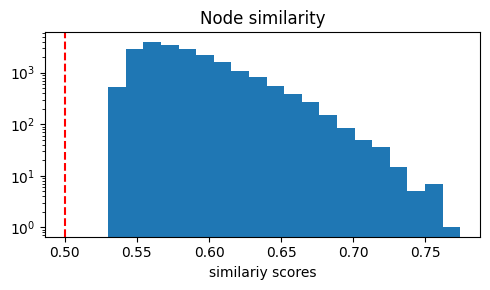

In [18]:
# MNN between E15_5 RNA spot and E18_5 RNA spot 
adata_E15E18rna = ug.tl.infer_edges(E15_rna_adata_fltr, E18_rna_adata_fltr, n_components=15, k=15)
ug.pl.node_similarity(adata_E15E18rna,cutoff=0.5)
adata_E15E18rna

Gene scores are being calculated for the first time
`use_precomputed` has been ignored
Processing: 0.0%
Processing: 20.0%
Gene scores are being calculated for the first time
`use_precomputed` has been ignored
Processing: 0.0%
Processing: 20.0%
#shared features: 35976
Performing randomized SVD ...
Searching for mutual nearest neighbors ...
20578 edges are selected
#selected edges: 20578


AnnData object with n_obs × n_vars = 1949 × 2129
    obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'src', 'Ground Truth'
    var: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'src'
    obsm: 'svd'
    varm: 'svd'
    layers: 'unig'

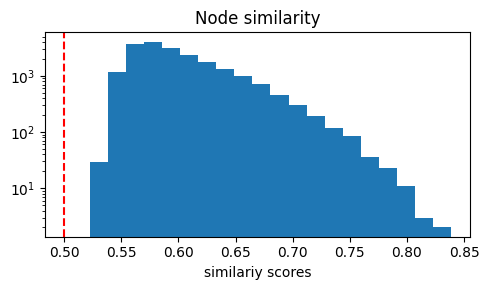

In [19]:
# MNN between E15_5 ATAC spot and E18_5 ATAC spot 
E15_GA = ug.tl.gene_scores(E15_atac_adata_fltr, genome='mm10',use_gene_weight=True, use_top_pcs=False)
E18_GA = ug.tl.gene_scores(E18_atac_adata_fltr, genome='mm10',use_gene_weight=True, use_top_pcs=False)
sc.pp.normalize_total(E15_GA)
sc.pp.log1p(E15_GA)
sc.pp.normalize_total(E18_GA)
sc.pp.log1p(E18_GA)

adata_E15E18atac = ug.tl.infer_edges(E15_GA, E18_GA, feature = None, n_components=15, k=15)
ug.pl.node_similarity(adata_E15E18atac,cutoff=0.5)
adata_E15E18atac

In [20]:
# merge MNNs
new_X = adata_E15E18rna.X + adata_E15E18atac.X
adata_MNN_all = AnnData(X=new_X, obs=adata_E15E18rna.obs.copy(), var=adata_E15E18atac.var.copy())

adata_MNN_all.write(workdir+"adata_MNN_final.h5ad")
adata_MNN_all

AnnData object with n_obs × n_vars = 1949 × 2129
    obs: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'Ground_Truth'
    var: 'Sample', 'TSSEnrichment', 'ReadsInTSS', 'ReadsInPromoter', 'ReadsInBlacklist', 'PromoterRatio', 'PassQC', 'NucleosomeRatio', 'nMultiFrags', 'nMonoFrags', 'nFrags', 'nDiFrags', 'Gex_RiboRatio', 'Gex_nUMI', 'Gex_nGenes', 'Gex_MitoRatio', 'BlacklistRatio', 'array_col', 'array_row', 'ReadsInPeaks', 'FRIP', 'ATAC_Clusters', 'RNA_Clusters', 'Combined_Clusters', 'Combined_Clusters_annotation', 'src'

# Generate graph

In [21]:
E15_rna_adata_fltr = sc.read_h5ad(workdir +"E15_RNA_adata_fltr_final.h5ad")
E18_rna_adata_fltr = sc.read_h5ad(workdir+"E18_RNA_adata_fltr_final.h5ad")
E15_atac_adata_fltr = sc.read_h5ad(workdir+"E15_ATAC_adata_fltr_final.h5ad")
E18_atac_adata_fltr = sc.read_h5ad(workdir+"E18_ATAC_adata_fltr_final.h5ad")
adata_C_E15 = sc.read_h5ad(workdir+"E15_InnerCell_final.h5ad")
adata_C_E18 = sc.read_h5ad(workdir+"E18_InnerCell_final.h5ad")
adata_PM = sc.read_h5ad(workdir+"adata_PeakMotif_final.h5ad")
adata_GP = sc.read_h5ad(workdir+"adata_GenePeak_final.h5ad")
adata_MNN_all = sc.read_h5ad(workdir+"adata_MNN_final.h5ad")

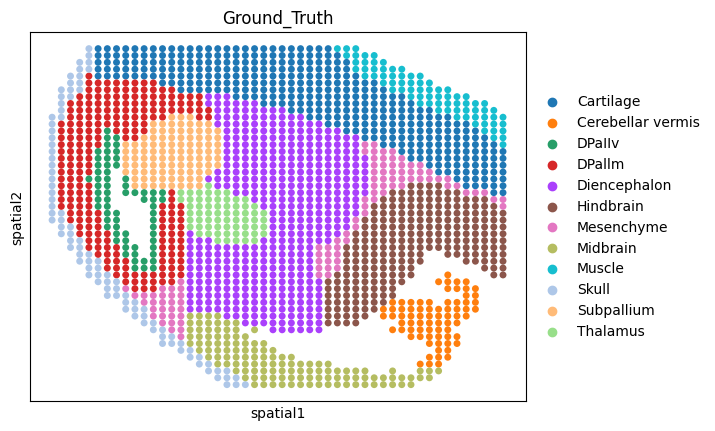

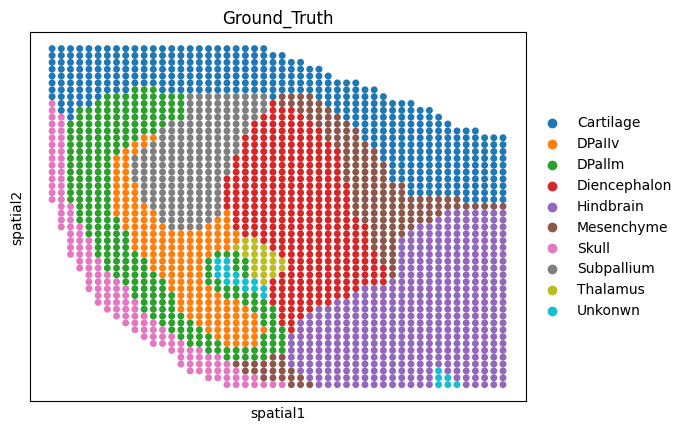

In [22]:
sc.pl.embedding(E15_rna_adata_fltr, basis='spatial', color=['Ground_Truth'], size=100)
sc.pl.embedding(E18_rna_adata_fltr, basis='spatial', color=['Ground_Truth'], size=100)

In [23]:
ug.gen_graph(list_CP=[E15_atac_adata_fltr,E18_atac_adata_fltr],
             list_CG=[E15_rna_adata_fltr,E18_rna_adata_fltr],
             list_PM=[adata_PM],
             list_CC_Spatial=[adata_C_E15,adata_C_E18],
             list_CC_Anchor=[adata_MNN_all],
             list_GP=[adata_GP],
             weight_CP = 3,
             weight_PM = 1,
             weight_CC_Spatial = 5,
             weight_CC_Anchor = 5,
             weight_GP = 1,
             copy=False,
             dirname='graph_Integration')

`unig` does not exist in anndata 0 in `list_CP`.`.X` is being used instead.
relation0: source: C, destination: P
#edges: 5201213
`unig` does not exist in anndata 1 in `list_CP`.`.X` is being used instead.
relation1: source: C2, destination: P
#edges: 4287799
`unig` does not exist in anndata 0 in `list_PM`.`.X` is being used instead.
relation2: source: P, destination: M
#edges: 231389
relation3: source: C, destination: G
#edges: 185492
relation4: source: C, destination: G
#edges: 296365
relation5: source: C, destination: G
#edges: 342991
relation6: source: C, destination: G
#edges: 241562
relation7: source: C, destination: G
#edges: 60229
relation8: source: C2, destination: G
#edges: 170611
relation9: source: C2, destination: G
#edges: 280934
relation10: source: C2, destination: G
#edges: 293160
relation11: source: C2, destination: G
#edges: 150671
relation12: source: C2, destination: G
#edges: 11648
`unig` does not exist in anndata 0 in `list_CC_Spatial`.`.X` is being used instead.
rel

# Training

In [24]:
pbg_training_stages = [
    {
        "name": "stage1_pretrain",
        "output": "model_0",
        "params": {
            "workers": 12,
            "lr": 0.1,
            "num_epochs": 10,
        },
    },
    {
        "name": "stage2_joint_finetune",
        "resume_from_previous": True,
        "params": {
            "workers": 12,
            "lr": 0.01,
            "num_epochs": 20,
            "alpha_ot_rna": 1e4,
            "alpha_ot_atac": 2e4,
            "alpha_triplet": 1000,
            "alpha_ot_gp": 2000,
            "begin_triplet_epoch": 10,
            "triplet_update_freq": 2,
        },
    },
]

pbg_configs = ug.run_training_stages(
    base_params=ug.settings.pbg_params,
    stages=pbg_training_stages,
)

=============== Start stage1_pretrain ===============
Random seeds set to 42 for reproducibility
Auto-estimated weight decay: 2.983496E-03
Training mode: standard
Converting input data...
[2026-08-21 11:01:41.891743] Using the 17 relation types given in the config
[2026-08-21 11:01:41.892315] Searching for the entities in the edge files...


[2026-08-21 11:01:53.724445] Entity type C:
[2026-08-21 11:01:53.725716] - Found 1949 entities
[2026-08-21 11:01:53.726036] - Removing the ones with fewer than 1 occurrences...
[2026-08-21 11:01:53.726631] - Left with 1949 entities
[2026-08-21 11:01:53.726898] - Shuffling them...
[2026-08-21 11:01:53.727806] Entity type C2:
[2026-08-21 11:01:53.728078] - Found 2129 entities
[2026-08-21 11:01:53.728332] - Removing the ones with fewer than 1 occurrences...
[2026-08-21 11:01:53.728797] - Left with 2129 entities
[2026-08-21 11:01:53.729047] - Shuffling them...
[2026-08-21 11:01:53.730484] Entity type G:
[2026-08-21 11:01:53.730723] - Found 857 entities
[2026-08-21 11:01:53.730959] - Removing the ones with fewer than 1 occurrences...
[2026-08-21 11:01:53.731302] - Left with 857 entities
[2026-08-21 11:01:53.731538] - Shuffling them...
[2026-08-21 11:01:53.732028] Entity type P:
[2026-08-21 11:01:53.732263] - Found 33327 entities
[2026-08-21 11:01:53.732486] - Removing the ones with fewer th

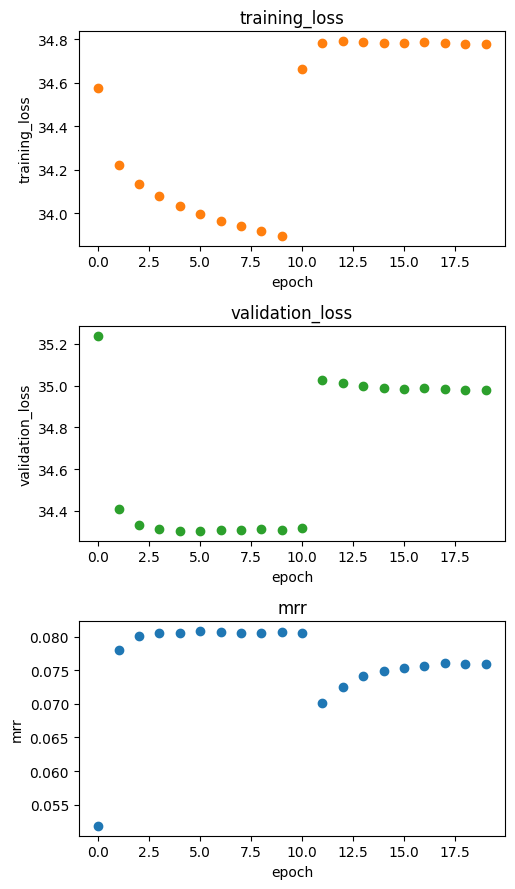

In [25]:
dict_config_s2 = pbg_configs["stage2_joint_finetune"]
ug.settings.pbg_params = dict_config_s2
ug.pl.pbg_metrics(fig_ncol=1)

# Post-training analysis

In [26]:
dict_adata = ug.tl.read_embedding()
dict_adata

{'C': AnnData object with n_obs × n_vars = 1949 × 50,
 'P': AnnData object with n_obs × n_vars = 33327 × 50,
 'C2': AnnData object with n_obs × n_vars = 2129 × 50,
 'G': AnnData object with n_obs × n_vars = 857 × 50,
 'M': AnnData object with n_obs × n_vars = 107 × 50}

In [27]:
adata_C = dict_adata['C']
adata_C2 = dict_adata['C2']
adata_G = dict_adata['G']  # embeddings for genes
adata_P = dict_adata['P']  # embeddings for peaks
adata_M = dict_adata['M']  # embeddings for motifs

adata_M.obs.index = 'M_'+adata_M.obs.index
adata_C.obs["entity_anno"] = "Cell1"
adata_C2.obs["entity_anno"] = "Cell2"
adata_G.obs["entity_anno"] = "Gene"
adata_P.obs["entity_anno"] = "Peak"
adata_M.obs["entity_anno"] = "Motif"

adata_C.obs['Ground_Truth'] = E15_rna_adata_fltr[adata_C.obs_names,:].obs['Ground_Truth'].copy()
adata_C.obsm['spatial'] = E15_rna_adata_fltr[adata_C.obs_names,:].obsm['spatial'].copy()
adata_C2.obs['Ground_Truth'] = E18_rna_adata_fltr[adata_C2.obs_names,:].obs['Ground_Truth'].copy()
adata_C2.obsm['spatial'] = E18_rna_adata_fltr[adata_C2.obs_names,:].obsm['spatial'].copy()

In [28]:
# Save embedding AnnData objects for downstream analysis.
import pickle
adata_dict = {
    'C': adata_C,
    'C2': adata_C2,
    'G': adata_G,
    'P': adata_P,
    'M': adata_M
}

with open(workdir+'MISAR-seq_UniG_integration_adata_dict.pkl', 'wb') as f:
    pickle.dump(adata_dict, f)
print(f"Saved AnnData dictionary to {workdir+'MISAR-seq_UniG_integration_adata_dict.pkl'}")

Saved AnnData dictionary to /home/nas3/biod/yangchenghui/proj2/proj2_on_mouse_embryonic/UniG_result/MISAR-seq_UniG_integration_adata_dict.pkl


visualize embeddings of spots

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


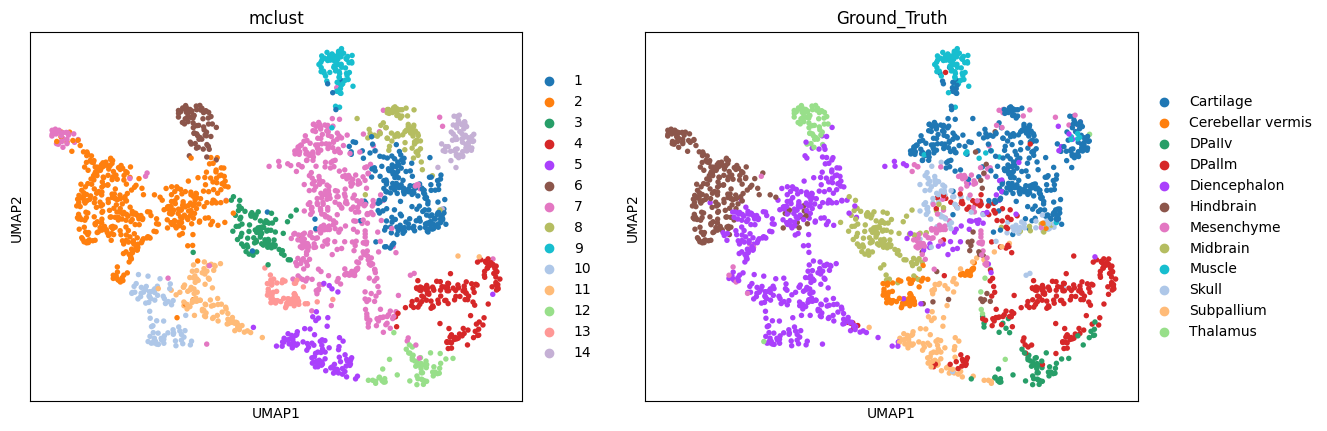

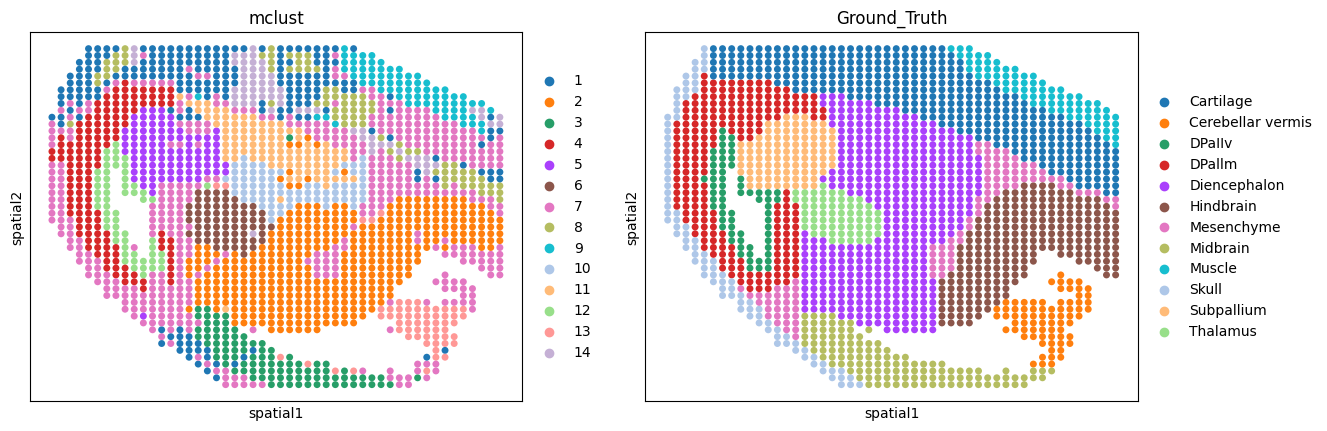

In [29]:
sc.pp.neighbors(adata_C)
sc.tl.umap(adata_C)
ug.tl.mclust_R(adata_C,14)
sc.pl.umap(adata_C, color=["mclust","Ground_Truth"])
sc.pl.embedding(adata_C, basis='spatial', color=["mclust",'Ground_Truth'], size=100)

fitting ...
  |======================================================================| 100%


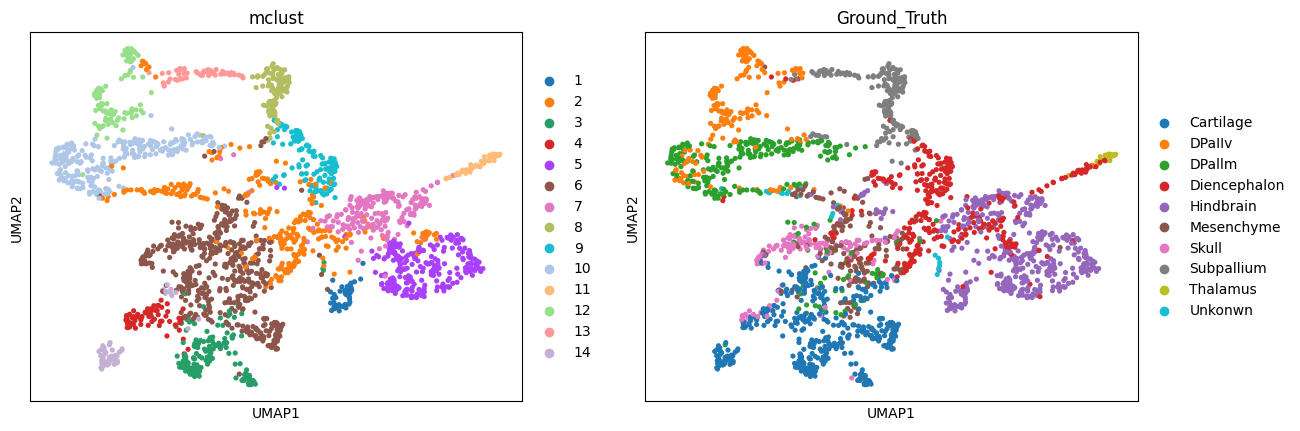

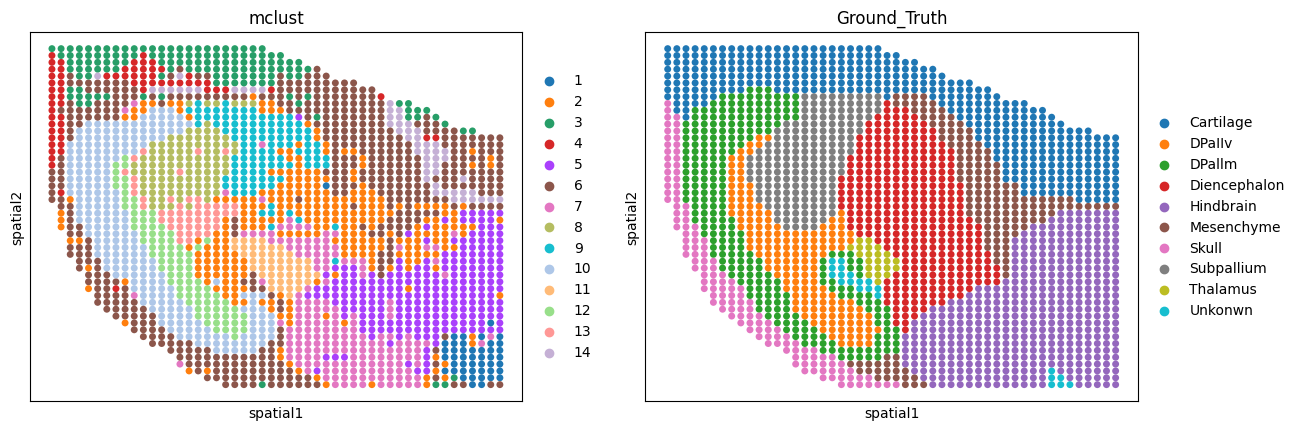

In [30]:
sc.pp.neighbors(adata_C2)
sc.tl.umap(adata_C2)
ug.tl.mclust_R(adata_C2, 14)
sc.pl.umap(adata_C2, color=["mclust","Ground_Truth"])
sc.pl.embedding(adata_C2, basis='spatial', color=["mclust",'Ground_Truth'], size=100)

Integration of the two spots embedding spaces

/tmp/ipykernel_3383645/2248257854.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined = adata_C.concatenate(adata_C2, join='inner')


AnnData object with n_obs × n_vars = 4078 × 50
    obs: 'entity_anno', 'Ground_Truth', 'mclust', 'batch'
    obsm: 'spatial', 'X_umap'
fitting ...
  |======================================================================| 100%


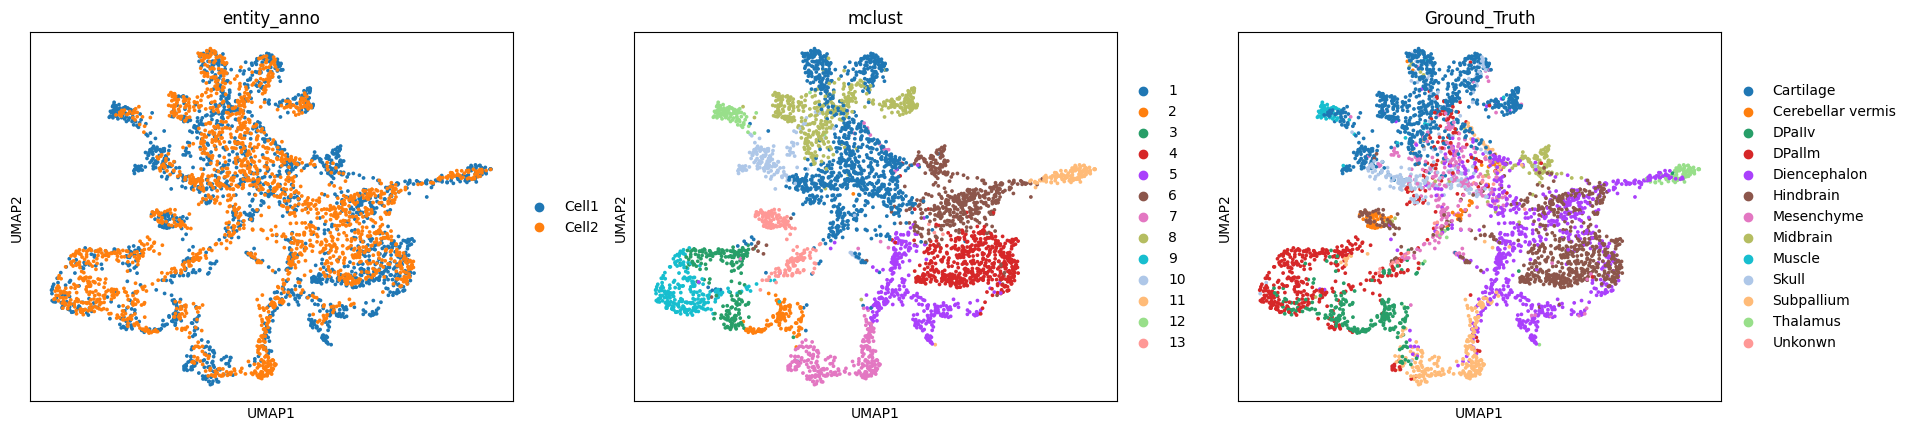

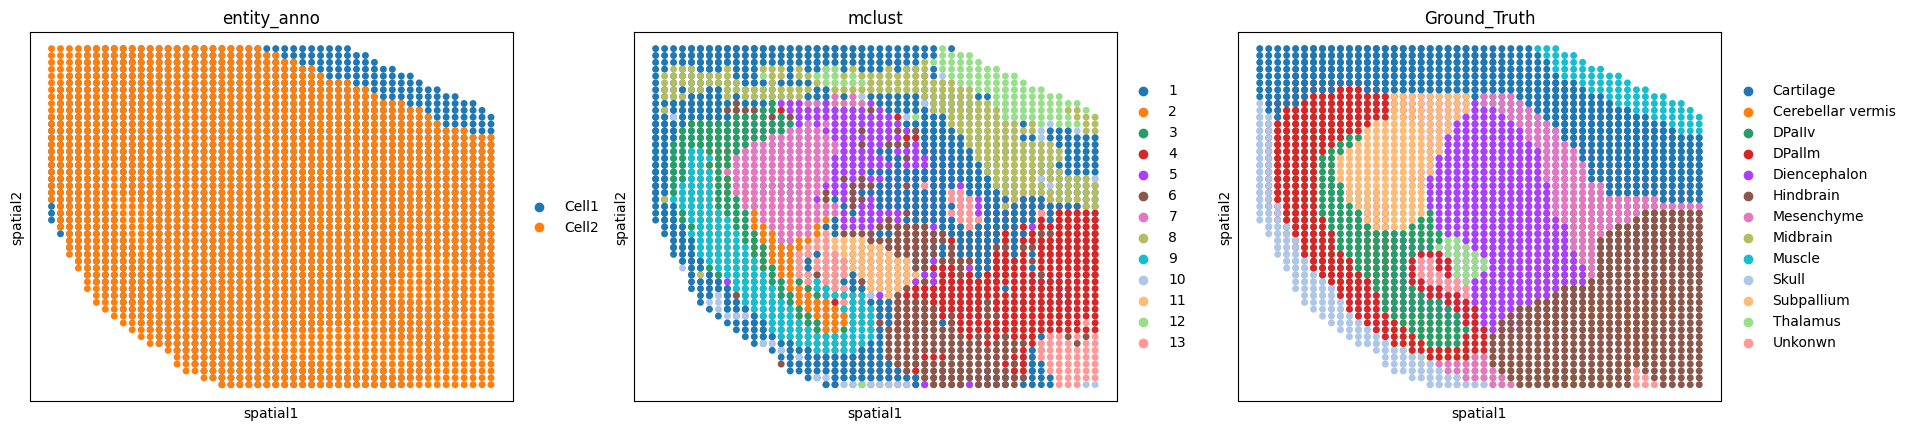

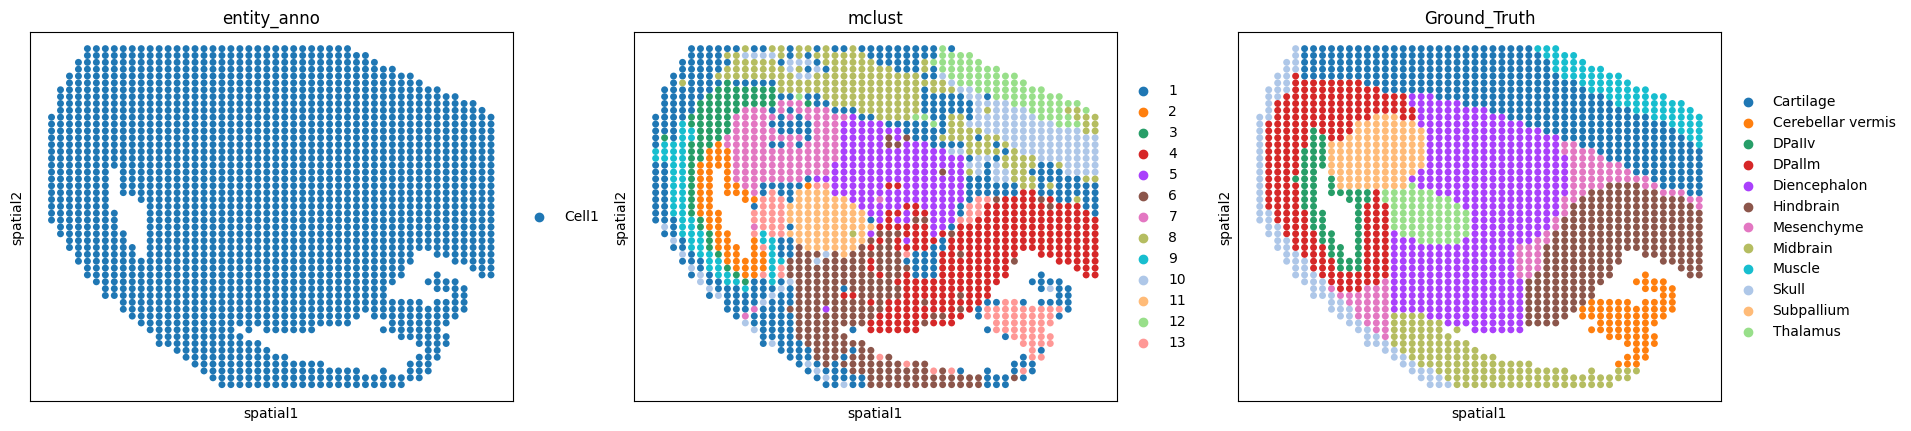

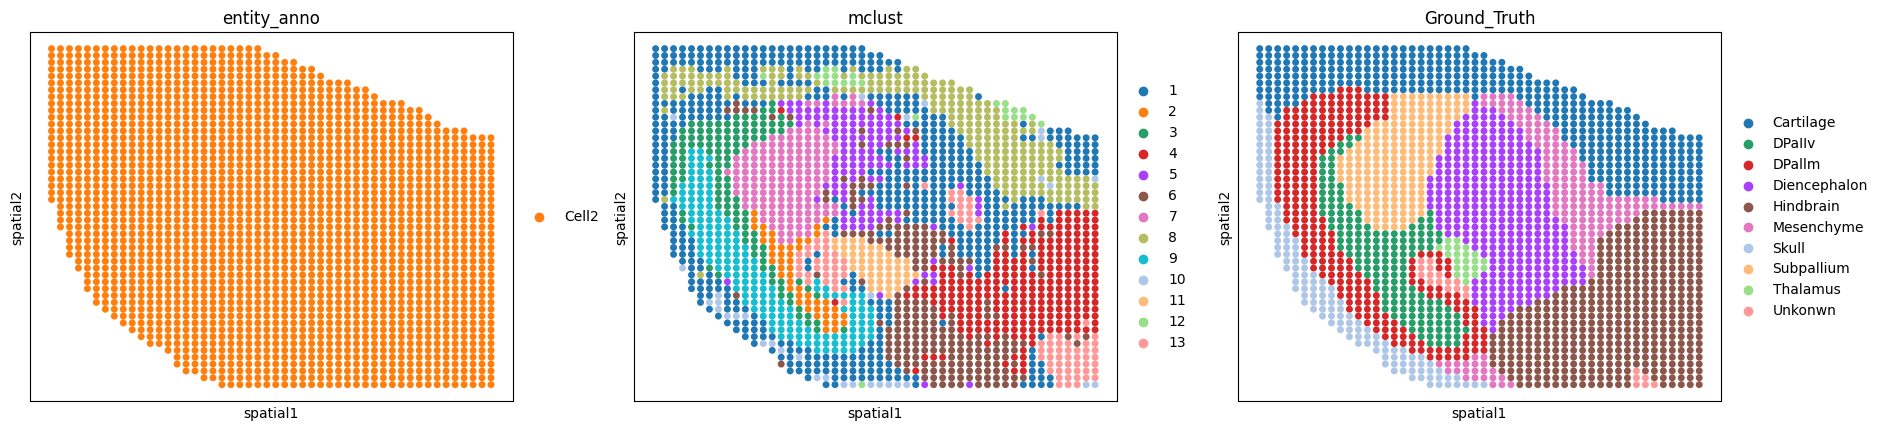

In [31]:
combined = adata_C.concatenate(adata_C2, join='inner')
print(combined)

sc.pp.neighbors(combined)
sc.tl.umap(combined)
ug.tl.mclust_R(combined,13)
sc.pl.umap(combined, color=["entity_anno","mclust","Ground_Truth"])
sc.pl.embedding(combined, basis='spatial', color=["entity_anno","mclust",'Ground_Truth'], size=100)

subset_adata = combined[combined.obs["entity_anno"].isin(["Cell1"])]
sc.pl.embedding(subset_adata, basis='spatial', color=["entity_anno","mclust","Ground_Truth"], size=100)

subset_adata = combined[combined.obs["entity_anno"].isin(["Cell2"])]
sc.pl.embedding(subset_adata, basis='spatial', color=["entity_anno","mclust","Ground_Truth"], size=100)